In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


status,ok
model,
baseline,39
tactile,13
contact_gated,39


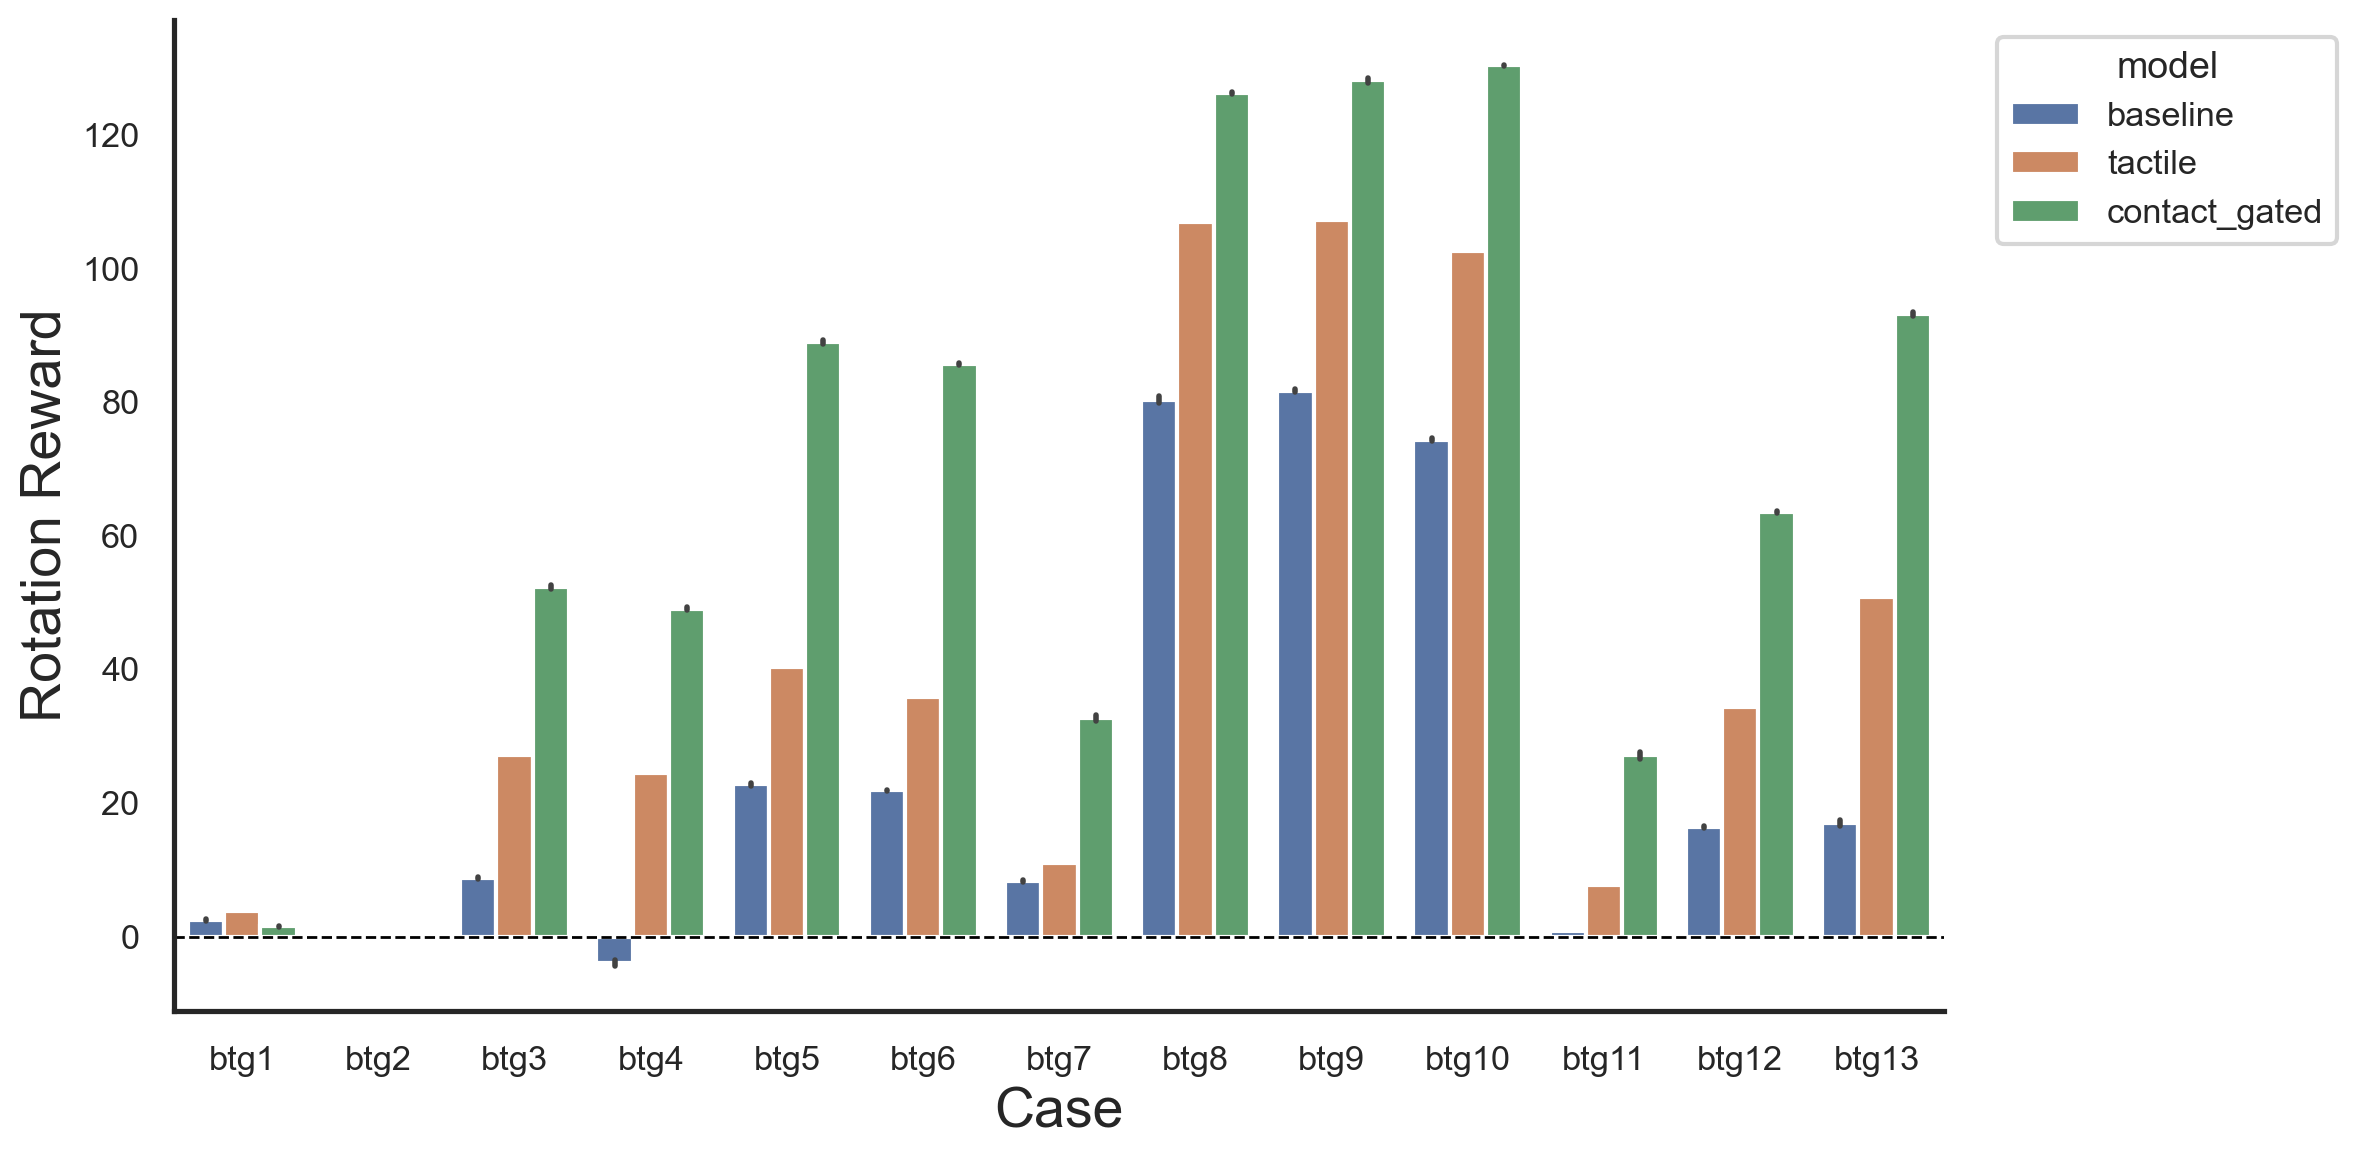

In [27]:
CSV_DIR = Path('eval_csvs')
RUNS = {
    'baseline': 'fullbaseline_04291133.csv',
    'tactile': 'naivetactile.csv',
    'contact_gated': 'asym_contact_gated_v2.csv'
}
METRICS = ['reward', 'eps_length', 'rotate_reward', 'lin_vel_x100', 'command_torque']

frames = []
for model, filename in RUNS.items():
    df_run = pd.read_csv(CSV_DIR / filename)
    df_run['model'] = model
    for metric in METRICS:
        if metric not in df_run.columns:
            df_run[metric] = pd.NA
    frames.append(df_run)

df = pd.concat(frames, ignore_index=True)
df['case_name'] = df['case_name'].str.split('_').str[2]
df[METRICS] = df[METRICS].apply(pd.to_numeric, errors='coerce')

status_summary = (
    df.groupby(['model', 'status'], dropna=False)
      .size()
      .unstack(fill_value=0)
      .reindex(RUNS.keys())
)
display(status_summary)

plot_df = df.dropna(subset=['reward']).copy()

fig, ax = plt.subplots(figsize=(12, 6), dpi=200)
sns.barplot(
    ax=ax,
    data=plot_df,
    x='case_name',
    y='reward',
    hue='model',
    errorbar='sd',
    err_kws={'linewidth': 2},
    hue_order=list(RUNS.keys()),
)
ax.set_xlabel('Case', fontsize=20)
ax.set_ylabel('Rotation Reward', fontsize=20)
ax.tick_params(axis='x')
ax.legend(title='model', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(color='black', linewidth=1.0, linestyle='--')
fig.tight_layout()
